In [1]:
import json
import networkx as nx
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt


In [2]:
# Load the network JSON (node-link format exported by networkx)
with open('../data/Emails_Graph_kmeans.json', 'r') as f:
    data = json.load(f)

# Build graph manually (safe across networkx versions)
G = nx.Graph()
for node in data['nodes']:
    G.add_node(node['id'], community=node['community'],
               cluster_label=node['cluster_label'], degree=node['degree'])
for link in data['links']:
    G.add_edge(link['source'], link['target'])

# Index node metadata for quick lookup
node_meta = {n['id']: n for n in data['nodes']}

print(f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")
print(f"Clusters: {sorted(set(n['cluster_label'] for n in data['nodes']))}")


Nodes: 153  |  Edges: 984
Clusters: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [3]:
# Color palette — one color per k-means cluster label (0–9)
CLUSTER_COLORS = {
    '0': '#e6194b',  # red
    '1': '#3cb44b',  # green
    '2': '#4363d8',  # blue
    '3': '#f58231',  # orange
    '4': '#911eb4',  # purple
    '5': '#42d4f4',  # cyan
    '6': '#f032e6',  # magenta
    '7': '#bfef45',  # lime
    '8': '#fabed4',  # pink
    '9': '#469990',  # teal
}


In [4]:
# Force-directed layout
pos = nx.spring_layout(G, seed=42, k=0.6)

# --- Edge traces ---
edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode='lines',
    line=dict(width=0.5, color='#aaaaaa'),
    hoverinfo='none'
)

# --- Node traces ---
node_x, node_y, colors, sizes, hover_text = [], [], [], [], []
for node in G.nodes():
    x, y = pos[node]
    meta   = node_meta.get(node, {})
    cluster = str(meta.get('cluster_label', '0'))
    degree  = meta.get('degree', 1)

    node_x.append(x)
    node_y.append(y)
    colors.append(CLUSTER_COLORS.get(cluster, '#aaaaaa'))
    sizes.append(max(8, degree * 2))
    hover_text.append(f"<b>{node}</b><br>Cluster: {cluster}<br>Degree: {degree}")

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hovertext=hover_text,
    hoverinfo='text',
    marker=dict(
        color=colors,
        size=sizes,
        line=dict(width=1, color='white')
    )
)

# --- Figure ---
fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title='Enron Email Network — colored by K-Means Cluster, sized by Degree',
        showlegend=False,
        hovermode='closest',
        paper_bgcolor='#1a1a2e',
        plot_bgcolor='#1a1a2e',
        font=dict(color='white'),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        height=800,
        margin=dict(l=10, r=10, t=50, b=10)
    )
)
fig.show()


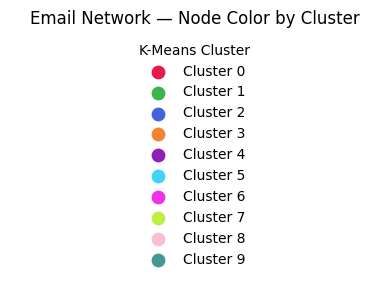

In [5]:
# Static legend — cluster → color
fig, ax = plt.subplots(figsize=(4, 3))
for label, color in sorted(CLUSTER_COLORS.items(), key=lambda x: int(x[0])):
    ax.scatter([], [], c=color, label=f'Cluster {label}', s=80)
ax.legend(title='K-Means Cluster', loc='center', frameon=False)
ax.axis('off')
plt.title('Email Network — Node Color by Cluster')
plt.tight_layout()
plt.show()
